# TF-IDF + Logistic Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Загрузка данных

In [2]:
df = pd.read_csv("../data/ru-hard-detection-clean.csv")

df["label"] = df["source"].map({
    "human": 0,
    "ai": 1
})
df['stratify_col'] = df['label'].astype(str) + "_" + df['dataset'].astype(str)
df['group_id'] = df['dataset'] + "_" + df['id'].astype(str)
df.iloc[478:482]

,id,text,model,source,dataset,label,stratify_col,group_id
478,479,"родине. Кассиль не идеализирует своих героев, ...",deepseek-chat,ai,Corus Essays,1,1_Corus Essays,Corus Essays_479
479,480,"предубеждениями, доказывая, что в борьбе за Ро...",gemini-2.0-flash,ai,Corus Essays,1,1_Corus Essays,Corus Essays_480
480,1,Период с 1922 по 1939 год — время становления ...,NaN,human,Corus Essays,0,0_Corus Essays,Corus Essays_1
481,2,"Время, в которое развернулась деятельность зна...",NaN,human,Corus Essays,0,0_Corus Essays,Corus Essays_2


### Предобработка текста

In [3]:
import pymorphy3
import nltk
from nltk.tokenize import word_tokenize
# nltk.download("punkt")
morph = pymorphy3.MorphAnalyzer()


def clean_text(text: str):
    text = text.lower()
    tokens = word_tokenize(text)    
    clean_tokens = []
    for word in tokens:
        if word in '.,!?':
            clean_tokens.append(word)
        else:
            clean_tokens.append(morph.parse(word)[0].normal_form)
            
    return " ".join(clean_tokens)

In [4]:
df['cleaned_text'] = df['text'].apply(clean_text)

### Train / test split

In [5]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit

In [6]:
# X_train, X_test, y_train, y_test = train_test_split(
#     df["cleaned_text"],
#     df["label"],
#     test_size=0.2,
#     random_state=42,
#     stratify=df["stratify_col"]
# )

In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df["cleaned_text"], df["label"], groups=df["group_id"]))

X_train = df["cleaned_text"].iloc[train_idx]
X_test = df["cleaned_text"].iloc[test_idx]
y_train = df["label"].iloc[train_idx]
y_test = df["label"].iloc[test_idx]

### Сборка модели

#### Настройка пайплайна

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

In [11]:
experiments = {
    "LogisticRegression": {
        "model": Pipeline([
            ("tfidf", TfidfVectorizer(        
                ngram_range=(1,3)
            )),
            ("clf", LogisticRegression(
                solver='liblinear',
                max_iter=1000,
                # n_jobs=-1,
                random_state=42
            ))
        ]),
        "params": {
            'tfidf__max_features': [10000, 30000, 50000],
            'clf__C': [0.1, 1, 10, 100],
            'clf__penalty': ['l1', 'l2']
        }
    },
    "NaiveBayes": {
        "model": Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 3))),
            ("clf", MultinomialNB())
        ]),
        "params": {
            "tfidf__max_features": [10000, 30000, 50000],
            "clf__alpha": [0.01, 0.1, 0.5, 1.0] # Главный параметр Баеса
        }
    },
    "RandomForest": {
        "model": Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 3))),
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "params": {
            "tfidf__max_features": [10000, 20000],
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 10, 20]
        }
    },
    "CatBoost": {
        "model": Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 3))),
            ("clf", CatBoostClassifier(thread_count=-1, silent=True, task_type="GPU", devices='0'))
        ]),
        "params": {
            "tfidf__max_features": [10000, 30000],
            "clf__iterations": [200, 500],
            "clf__depth": [4, 6]
        }
    }
}

#### Настраиваем сетку параметров

In [12]:
best_results = {}
for name, exp in experiments.items():
    print(f"\n=== Запуск GridSearchCV для модели: {name} ===")
    n_jobs = 1 if name == "CatBoost" else -1
    grid_search = GridSearchCV(
        exp["model"], 
        exp["params"], 
        cv=5, 
        scoring='f1', 
        n_jobs=n_jobs, 
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
 
    best_results[name] = {        
        "best_model": grid_search.best_estimator_,
        "best_score": grid_search.best_score_,
        "best_params": grid_search.best_params_
    }
    
    print(f"Результат {name}: F1 = {grid_search.best_score_:.4f}")
    print(f"Параметры: {grid_search.best_params_}")


=== Запуск GridSearchCV для модели: LogisticRegression ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\danil\PycharmProjects\AiTextDetector\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Результат LogisticRegression: F1 = 0.9498
Параметры: {'clf__C': 100, 'clf__penalty': 'l2', 'tfidf__max_features': 30000}

=== Запуск GridSearchCV для модели: NaiveBayes ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Результат NaiveBayes: F1 = 0.9071
Параметры: {'clf__alpha': 0.01, 'tfidf__max_features': 50000}

=== Запуск GridSearchCV для модели: RandomForest ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Результат RandomForest: F1 = 0.9222
Параметры: {'clf__max_depth': 20, 'clf__n_estimators': 200, 'tfidf__max_features': 10000}

=== Запуск GridSearchCV для модели: CatBoost ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Результат CatBoost: F1 = 0.9461
Параметры: {'clf__depth': 6, 'clf__iterations': 500, 'tfidf__max_features': 10000}


#### Лучшая модель

In [13]:
winner_name = max(best_results, key=lambda x: best_results[x]["best_score"])
print(f"\n🏆 Победитель: {winner_name} с F1 = {best_results[winner_name]['best_score']:.4f}")


🏆 Победитель: LogisticRegression с F1 = 0.9498


### Метрики

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)

In [15]:
model_metrics = {}
for name, res in best_results.items():
    model = res["best_model"]
    y_pred = model.predict(X_test)

    model_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
    }

### Матрица ошибок

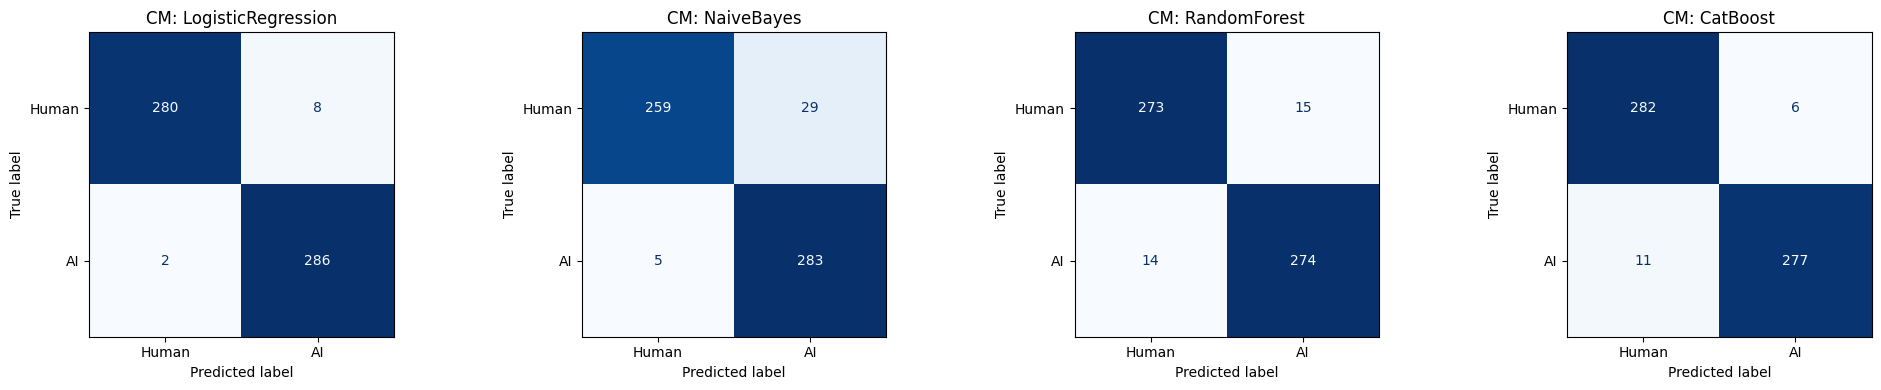

In [16]:
n_models = len(best_results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for i, (name, res) in enumerate(best_results.items()):
    model = res["best_model"]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"CM: {name}")

plt.tight_layout()
plt.show()

### Построение ROC-кривой

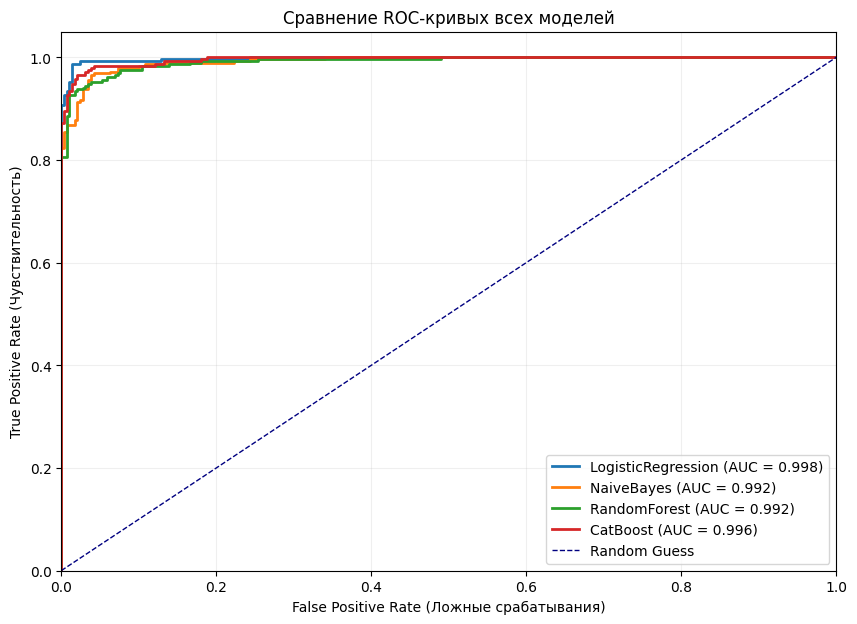

In [17]:
plt.figure(figsize=(10, 7))

for name, res in best_results.items():
    model = res["best_model"]
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('Сравнение ROC-кривых всех моделей')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

#### Таблица итоговых метрик

In [18]:
metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.sort_values(by="F1", ascending=False).round(4)

display(metrics_df)

,Accuracy,Precision,Recall,F1
LogisticRegression,0.9826,0.9728,0.9931,0.9828
CatBoost,0.9705,0.9788,0.9618,0.9702
RandomForest,0.9497,0.9481,0.9514,0.9497
NaiveBayes,0.9410,0.9071,0.9826,0.9433


### Сохраняем лучшую модель для дальнейшего инференса

In [19]:
import os
import joblib
import re

os.makedirs('../models', exist_ok=True)

for name, res in best_results.items():
    safe_name = re.sub(r'[^a-zA-Z0-9_]+', '_', name)
    path = f'../models/{safe_name}_model.pkl'
    
    joblib.dump(res["best_model"], path)